# Testing if the integrator works

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from simulation import Simulation
from wisdom_holman import WisdomHolman
from particles import Particles
from particle import Particle
from data_io import DataIO
import constants
from physics import Physics
import h5py
import tools

In [3]:
particles = Particles(constants.G)
particles.primary = "Sun"

'''
particles.add_particle(Particle(
    ptype=0, mass=2*10**30, radius=696340000, name="Sun",
    temperature=5772.0,
    a=0.0, e=0.0, inc=0.0, Omega=0.0, omega=0.0, theta=0.0,
    angles_in_degrees=False, primary="Sun"
))

particles.add_particle(Particle(
    ptype=1, mass=5.24*10**24, radius=6378000, name="Earth",
    a=1.496*10**11, e=0.0167, inc=0.0, Omega=0.0, omega=0.0, theta=0.0,
    angles_in_degrees=False, primary="Sun"
))


particles.add_particle(Particle(
    ptype=1, mass=6.39*10**23, radius=3389500, name="Mars",
    a=1.52*1.496*10**11, e=0.0934, inc=1.85, Omega=0.0, omega=0.0, theta=0.0,
    angles_in_degrees=True, primary="Sun"
))
'''

particles.add_particle(Particle(
    ptype=0, mass=1.0, radius=0.00465047, name='Sun',
    temperature=5772.0,
    a=0.0, e=0.0, inc=0.0, Omega=0.0, omega=0.0, theta=0.0,
    angles_in_degrees=False, primary='Sun'
))

particles.add_particle(Particle(
    ptype=1, mass=3.00274e-6, radius=4.26352e-5, name='Earth',
    a=1.0, e=0.0167, inc=0.0, Omega=0.0, omega=0.0, theta=0.0,
    angles_in_degrees=False, primary='Sun'
))

particles.add_particle(Particle(
    ptype=1, mass=3.00274e-6, radius=4.26352e-5, name='Mars',
    a=2.0, e=0.1167, inc=0.0, Omega=0.0, omega=0.0, theta=0.0,
    angles_in_degrees=False, primary='Sun'
))

print(particles._particles)

[Particle(name='Sun', ptype=0, m=1.0, r=0.00465047, pos=[0.0, 0.0, 0.0], vel=[0.0, 0.0, 0.0], hash=226624094), Particle(name='Earth', ptype=1, m=3.00274e-06, r=4.26352e-05, pos=[0.9833000000000001, 0.0, 0.0], vel=[0.0, 6.389015071057907, 0.0], hash=520537407), Particle(name='Mars', ptype=1, m=3.00274e-06, r=4.26352e-05, pos=[1.7666, 0.0, 0.0], vel=[0.0, 4.9955080760141355, 0.0], hash=526328850)]


In [5]:
run = Simulation(particles=particles, integrator=WisdomHolman(), dataio=DataIO(const_g=constants.G), physics=Physics())

In [16]:
run.run(t0=0.0, tf=30, dt=0.01, output_every_n=1, handle_collisions=False)

In [17]:
x_cart = [[5.4, 1.0, 0.0], [4.3, 3.2, 0.0], [0.0, 1.0, 0.0], [0.0, 2.0, 0.0]]
masses = [1.0, 2.0]
x_jac = tools.cart2jacobi(x_cart, masses, 2, None)
x_cart = tools.jacobi2cart(x_jac, masses, 2, None)
print(x_jac)
print(x_cart)

[ 4.66666667  2.46666667  0.         -1.1         2.2         0.
  0.          1.66666667  0.          0.          1.          0.        ]
[5.4 1.  0.  4.3 3.2 0.  0.  1.  0.  0.  2.  0. ]


In [18]:
import matplotlib.pyplot as plt

keys: ['Step_12', 'Step_13', 'Step_14'] ... Step_14
t[0], t[-1], len: 0.0 30.00000000000189 3001
pos shape: (3001, 3, 3)


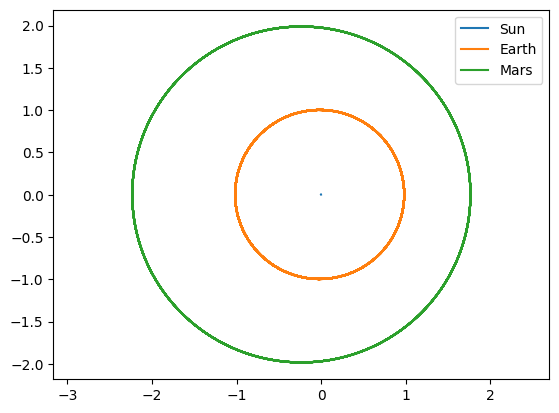

In [19]:
H5_PATH = "data.hdf5"

with h5py.File(H5_PATH, "r") as f:
    keys = sorted(
        [k for k in f.keys() if k.startswith("Step_")],
        key=lambda s: int(s.split("_")[1])
    )

    t_list, pos_list, vel_list = [], [], []
    for k in keys:
        g = f[k]
        t_list.append(g["time"][:])
        pos_list.append(g["pos"][:])
        vel_list.append(g["vel"][:])

t = np.concatenate(t_list)
pos = np.concatenate(pos_list)
vel = np.concatenate(vel_list)

# reshape if flattened (n_steps, 3N) -> (n_steps, N, 3)
if pos.ndim == 2:
    N = pos.shape[1] // 3
    pos = pos.reshape(pos.shape[0], N, 3)
if vel.ndim == 2:
    N2 = vel.shape[1] // 3
    vel = vel.reshape(vel.shape[0], N2, 3)

print("keys:", keys[:3], "...", keys[-1])
print("t[0], t[-1], len:", t[0], t[-1], len(t))
print("pos shape:", pos.shape)

# ---- pick indices: 0=Sun, 1=Earth ----
sun_i = 0
earth_i = 1
mars_i = 2

# Optional: mask out any rows where Earth got removed and became NaN
mask_e = np.isfinite(pos[:, earth_i, 0]) & np.isfinite(pos[:, earth_i, 1])
mask_m = np.isfinite(pos[:, mars_i, 0]) & np.isfinite(pos[:, mars_i, 1])

plt.figure()
plt.plot(pos[:, sun_i, 0], pos[:, sun_i, 1], label="Sun")
plt.plot(pos[mask_e, earth_i, 0], pos[mask_e, earth_i, 1], label="Earth")
plt.plot(pos[mask_m, mars_i, 0], pos[mask_m, mars_i, 1], label="Mars")
plt.axis("equal")
plt.legend()
plt.show()

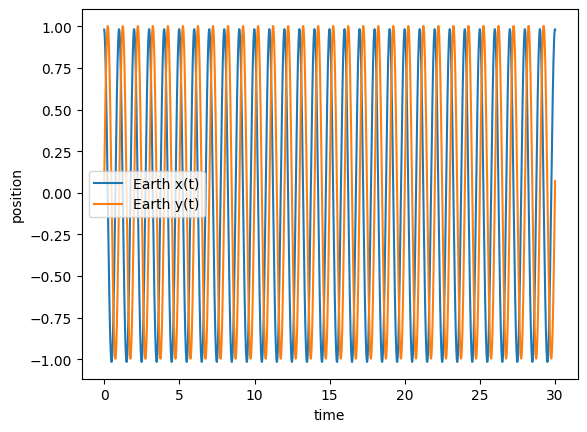

In [20]:
plt.figure()
plt.plot(t, pos[:, earth_i, 0], label="Earth x(t)")
plt.plot(t, pos[:, earth_i, 1], label="Earth y(t)")
plt.xlabel("time")
plt.ylabel("position")
plt.legend()
plt.show()

In [21]:
print("first 5 times:", t[:5])

print("first vel row:", vel[0])
print(vel[1])
print(vel[2])
print('pos rows')
print(pos[0], pos[1], pos[2], pos[3])

first 5 times: [0.   0.01 0.02 0.03 0.04]
first vel row: [[ 1.47012479e-05  1.38483958e-05  0.00000000e+00]
 [-4.24126407e-01  6.37472925e+00  0.00000000e+00]
 [-4.47181794e+00  3.97874197e-01  0.00000000e+00]]
[[ 1.59089892e-05  1.42724093e-05  0.00000000e+00]
 [-8.30258190e-01  6.33396659e+00  0.00000000e+00]
 [-4.46789923e+00  2.97427986e-01  0.00000000e+00]]
[[ 1.70992129e-05  1.47733479e-05  0.00000000e+00]
 [-1.23277385e+00  6.26694680e+00  0.00000000e+00]
 [-4.46176277e+00  1.97620613e-01  0.00000000e+00]]
pos rows
[[ 5.47618145e-06  2.04527555e-03  0.00000000e+00]
 [ 9.81092711e-01  6.84198359e-02  0.00000000e+00]
 [-5.49208543e-02  1.98040350e+00  0.00000000e+00]] [[ 5.62924507e-06  2.04541609e-03  0.00000000e+00]
 [ 9.74818509e-01  1.31985296e-01  0.00000000e+00]
 [-9.96213039e-02  1.98387950e+00  0.00000000e+00]] [[ 5.79430283e-06  2.04556125e-03  0.00000000e+00]
 [ 9.64499603e-01  1.95011630e-01  0.00000000e+00]
 [-1.44271446e-01  1.98635419e+00  0.00000000e+00]] [[ 5.97115

E0 = -8.890772568084084e-05
max |ΔE/E0| = 8.330955054676903e-10


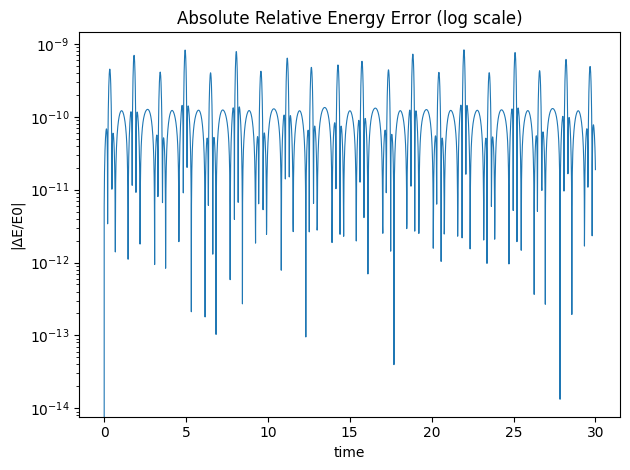

[-8.89077257e-05 -8.89077257e-05 -8.89077257e-05 -8.89077257e-05
 -8.89077257e-05 -8.89077257e-05 -8.89077257e-05 -8.89077257e-05
 -8.89077257e-05 -8.89077257e-05]


In [22]:
with h5py.File(H5_PATH, "r") as f:
    keys = sorted(
        [k for k in f.keys() if k.startswith("Step_")],
        key=lambda s: int(s.split("_")[1])
    )

    energy_list, t_list = [], []
    for k in keys:
        g = f[k]
        t_list.append(g["time"][:])
        energy_list.append(g["energy"][:])
       

energy = np.concatenate(energy_list)
t = np.concatenate(t_list)

mask = np.isfinite(energy) & np.isfinite(t)
t = t[mask]
energy = energy[mask]

E0 = energy[0]
dE = energy - E0
rel = dE / abs(E0)

print("E0 =", E0)
print("max |ΔE/E0| =", np.max(np.abs(rel)))

plt.figure()

# Absolute relative error (paper-style)
plt.semilogy(t, np.abs(dE/E0), lw=0.8)
plt.xlabel("time")
plt.ylabel("|ΔE/E0|")
plt.title("Absolute Relative Energy Error (log scale)")

plt.tight_layout()
plt.show()


print(energy[:10])

In [67]:
7.160830322892866e-10/2.0754249980515645e-10

3.4502958813811846

In [68]:
P = np.einsum("i,tij->tj", particles.masses, vel)   # total momentum vs time
dP = P - P[0]
print("max |ΔP| =", np.max(np.linalg.norm(dP, axis=1)))
print("max |ΔP|/|P0| =", np.max(np.linalg.norm(dP, axis=1)) / max(np.linalg.norm(P[0]), 1e-30))

max |ΔP| = 1.3145982598832311e-18
max |ΔP|/|P0| = 3.845567858847607e-14


In [12]:
with h5py.File(H5_PATH, "r") as f:
    keys = sorted(
        [k for k in f.keys() if k.startswith("Step_")],
        key=lambda s: int(s.split("_")[1])
    )

    temp = []
    for k in keys:
        g = f[k]
        temp.append(g["temperature"][:])
